# Week 2 EDA: Metal Surface Defect Dataset

This notebook provides a beginner-friendly EDA workflow for the checkpoint:
- dataset overview
- class and split distributions
- sample images
- image dimension analysis
- pixel intensity distribution
- observations and conclusion

In [1]:
from pathlib import Path
import random
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

In [2]:
# Prefer data/splits for Week 2, but allow data/splits_combined as fallback.
ROOT = Path('..')
PRIMARY_SPLITS = ROOT / 'data' / 'splits'
FALLBACK_SPLITS = ROOT / 'data' / 'splits_combined'
SPLITS_DIR = PRIMARY_SPLITS if PRIMARY_SPLITS.exists() else FALLBACK_SPLITS

if not SPLITS_DIR.exists():
    raise FileNotFoundError('No split folder found. Run scripts/split_dataset.py first.')

print(f'Using split directory: {SPLITS_DIR}')

Using split directory: ..\data\splits


In [3]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

def is_image_file(path: Path) -> bool:
    return path.suffix.lower() in IMAGE_EXTENSIONS

def collect_records(splits_dir: Path) -> pd.DataFrame:
    records = []
    for split in ['train', 'val', 'test']:
        split_dir = splits_dir / split
        if not split_dir.exists():
            continue
        for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
            for img_path in class_dir.rglob('*'):
                if img_path.is_file() and is_image_file(img_path):
                    records.append({'path': img_path, 'class_name': class_dir.name, 'split': split})
    return pd.DataFrame(records)

df = collect_records(SPLITS_DIR)
if df.empty:
    raise ValueError('No images found in split folders.')

print(f'Total images found: {len(df)}')
print(f'Number of classes: {df["class_name"].nunique()}')
df.head()

Total images found: 3861
Number of classes: 17


,path,class_name,split
0,..\data\splits\train\be_injured_by_a_collision...,be_injured_by_a_collision,train
1,..\data\splits\train\be_injured_by_a_collision...,be_injured_by_a_collision,train
2,..\data\splits\train\be_injured_by_a_collision...,be_injured_by_a_collision,train
3,..\data\splits\train\be_injured_by_a_collision...,be_injured_by_a_collision,train
4,..\data\splits\train\be_injured_by_a_collision...,be_injured_by_a_collision,train


In [4]:
# Class distribution table
class_counts = df['class_name'].value_counts().sort_index()
class_counts_df = class_counts.rename_axis('class_name').reset_index(name='count')
class_counts_df

,class_name,count
0,be_injured_by_a_collision,77
1,clean_sample,1018
2,coating_cracking,35
3,convex_powder,64
4,crazing,300
5,dirty_spot,209
6,drain_bottom,283
7,inclusion,300
8,non_conducting,39
9,orange_peel,90


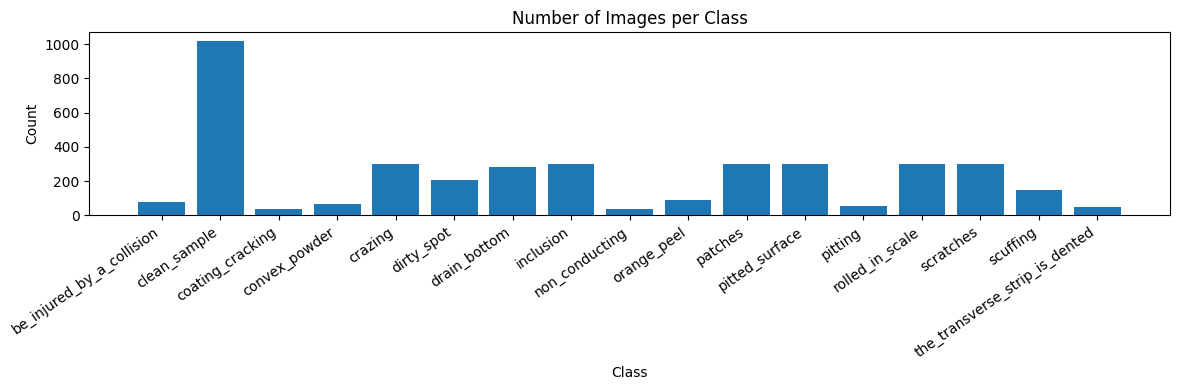

In [5]:
# Plot class distribution
plt.figure(figsize=(12, 4))
plt.bar(class_counts_df['class_name'], class_counts_df['count'])
plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

In [6]:
# Summary table by class and split
split_table = pd.crosstab(df['class_name'], df['split'])
for split_name in ['train', 'val', 'test']:
    if split_name not in split_table.columns:
        split_table[split_name] = 0
split_table = split_table[['train', 'val', 'test']]
split_table['total'] = split_table.sum(axis=1)
split_table.loc['TOTAL'] = split_table.sum(axis=0)
split_table

split,train,val,test,total
class_name,,,,
be_injured_by_a_collision,61,7,9,77
clean_sample,814,101,103,1018
coating_cracking,28,3,4,35
convex_powder,51,6,7,64
crazing,240,30,30,300
dirty_spot,167,20,22,209
drain_bottom,226,28,29,283
inclusion,240,30,30,300
non_conducting,31,3,5,39


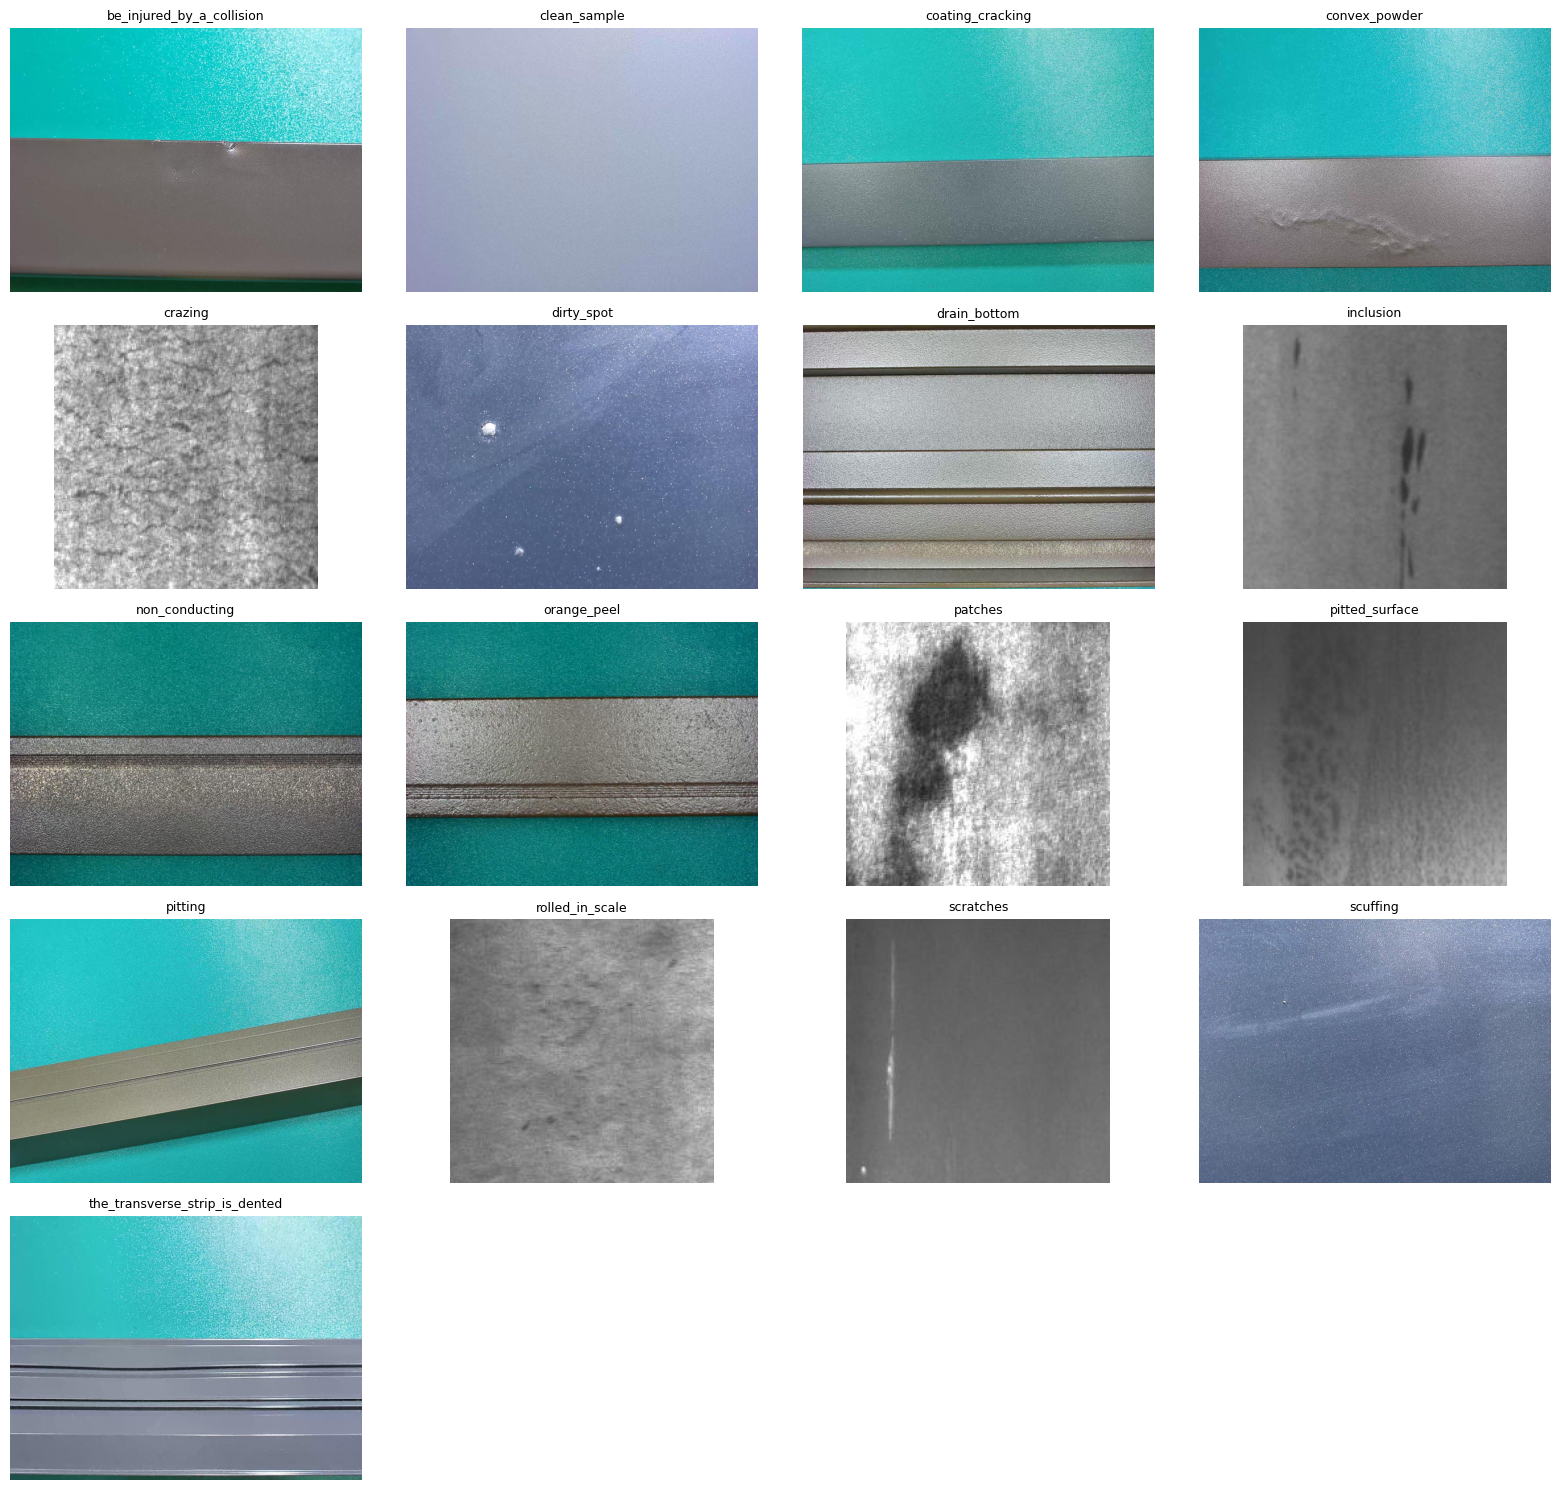

In [7]:
# Show one sample image from each class
class_to_path = {}
for row in df.itertuples(index=False):
    if row.class_name not in class_to_path:
        class_to_path[row.class_name] = row.path

classes = sorted(class_to_path.keys())
n_classes = len(classes)
n_cols = 4
n_rows = int(np.ceil(n_classes / n_cols))

plt.figure(figsize=(4 * n_cols, 3 * n_rows))
for i, class_name in enumerate(classes, start=1):
    with Image.open(class_to_path[class_name]) as img:
        arr = np.array(img)
    plt.subplot(n_rows, n_cols, i)
    if arr.ndim == 2:
        plt.imshow(arr, cmap='gray')
    else:
        plt.imshow(arr)
    plt.title(class_name, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

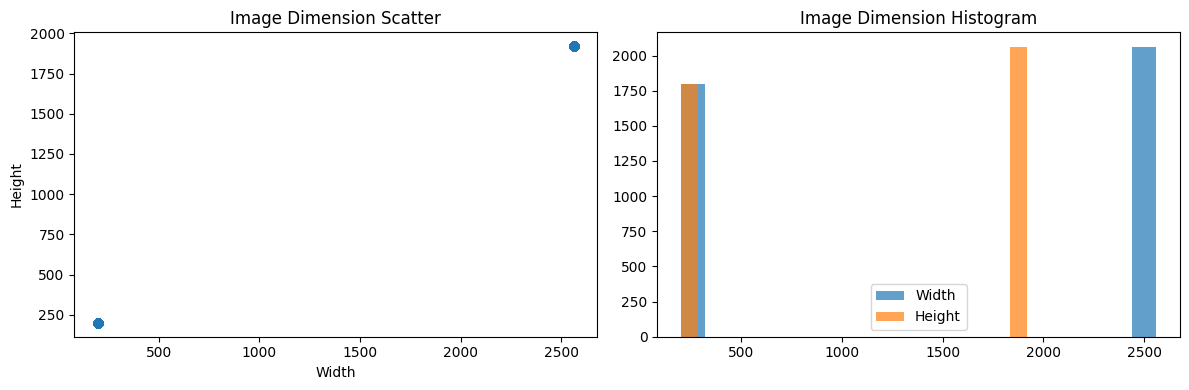

Unique sizes: 2


In [8]:
# Analyze image width/height distribution
widths = []
heights = []
for path in df['path']:
    with Image.open(path) as img:
        w, h = img.size
    widths.append(w)
    heights.append(h)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(widths, heights, alpha=0.25)
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Image Dimension Scatter')

plt.subplot(1, 2, 2)
plt.hist(widths, bins=20, alpha=0.7, label='Width')
plt.hist(heights, bins=20, alpha=0.7, label='Height')
plt.title('Image Dimension Histogram')
plt.legend()

plt.tight_layout()
plt.show()

print(f'Unique sizes: {len(set(zip(widths, heights)))}')

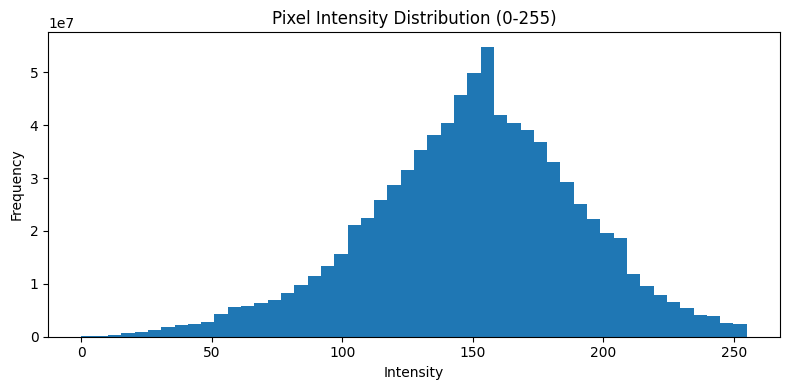

Pixel mean: 149.75
Pixel std: 40.74


In [9]:
# Pixel intensity distribution (grayscale) using a sample for speed
random.seed(42)
sample_paths = list(df['path'])
if len(sample_paths) > 300:
    sample_paths = random.sample(sample_paths, 300)

all_pixels = []
for path in sample_paths:
    with Image.open(path) as img:
        gray = img.convert('L')
        arr = np.array(gray).ravel()
    all_pixels.append(arr)

pixels = np.concatenate(all_pixels)
plt.figure(figsize=(8, 4))
plt.hist(pixels, bins=50)
plt.title('Pixel Intensity Distribution (0-255)')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'Pixel mean: {pixels.mean():.2f}')
print(f'Pixel std: {pixels.std():.2f}')

In [10]:
# Checkpoint-friendly numeric summary
total_images = int(len(df))
num_classes = int(df['class_name'].nunique())

split_counts = df['split'].value_counts()
train_count = int(split_counts.get('train', 0))
val_count = int(split_counts.get('val', 0))
test_count = int(split_counts.get('test', 0))

max_class = int(class_counts.max())
min_class = int(class_counts.min())
imbalance_ratio = max_class / max(1, min_class)

print('Dataset overview:')
print(f'- Total images: {total_images}')
print(f'- Number of classes: {num_classes}')
print('Split distribution:')
print(f'- Train: {train_count} ({train_count / total_images:.2%})')
print(f'- Val:   {val_count} ({val_count / total_images:.2%})')
print(f'- Test:  {test_count} ({test_count / total_images:.2%})')
print('Class balance summary:')
print(f'- Max class size: {max_class}')
print(f'- Min class size: {min_class}')
print(f'- Imbalance ratio (max/min): {imbalance_ratio:.2f}x')

Dataset overview:
- Total images: 3861
- Number of classes: 17
Split distribution:
- Train: 3085 (79.90%)
- Val:   379 (9.82%)
- Test:  397 (10.28%)
Class balance summary:
- Max class size: 1018
- Min class size: 35
- Imbalance ratio (max/min): 29.09x


In [11]:
# Save checkpoint-ready EDA figures for report screenshots
OUT_DIR = ROOT / 'outputs' / 'eda_figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 1) Class distribution bar chart
plt.figure(figsize=(12, 4))
plt.bar(class_counts_df['class_name'], class_counts_df['count'])
plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR / 'class_distribution.png', dpi=200)
plt.close()

# 2) Image dimension analysis
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(widths, heights, alpha=0.25)
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Image Dimension Scatter')

plt.subplot(1, 2, 2)
plt.hist(widths, bins=20, alpha=0.7, label='Width')
plt.hist(heights, bins=20, alpha=0.7, label='Height')
plt.title('Image Dimension Histogram')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'image_dimensions.png', dpi=200)
plt.close()

# 3) Pixel intensity histogram
plt.figure(figsize=(8, 4))
plt.hist(pixels, bins=50)
plt.title('Pixel Intensity Distribution (0-255)')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(OUT_DIR / 'pixel_intensity_distribution.png', dpi=200)
plt.close()

print('Saved EDA figures:')
print(f'- {OUT_DIR / "class_distribution.png"}')
print(f'- {OUT_DIR / "image_dimensions.png"}')
print(f'- {OUT_DIR / "pixel_intensity_distribution.png"}')

Saved EDA figures:
- ..\outputs\eda_figures\class_distribution.png
- ..\outputs\eda_figures\image_dimensions.png
- ..\outputs\eda_figures\pixel_intensity_distribution.png


## Observations

1. **Dataset overview**: The dataset contains **3861 images** across **17 classes**, which is enough for baseline model training and comparison.
2. **Split quality**: The split is close to the target 80/10/10 ratio with **3085 train (79.90%)**, **379 val (9.82%)**, and **397 test (10.28%)** samples.
3. **Class imbalance**: Distribution is skewed. The largest class has **1018** samples while the smallest has **35**, giving an imbalance ratio of **29.09x**.
4. **Resolution consistency**: There are only **2 unique image sizes**, which is manageable; optional resizing can still improve training consistency.
5. **Intensity behavior**: Pixel statistics are **mean = 149.75** and **std = 40.74**, indicating moderate brightness variation and non-trivial texture contrast.
6. **Most underrepresented classes**: `coating_cracking` and `non_conducting` have very low counts and may need augmentation or class weighting in model training.

## Conclusion

The Week 2 data pipeline is ready for baseline modeling: images were cleaned, classes were preserved, and reproducible train/validation/test splits were created using a fixed seed. EDA confirms that data quality is generally good, while class imbalance remains an important risk for model performance. In the next phase, class-aware augmentation or weighted loss can be used to improve minority-class recall and overall robustness.